In [1]:
!nvidia-smi

Fri Feb 27 10:57:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             25W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Import libraries

In [2]:
!git clone https://github.com/VuTrinhNguyenHoang/eX-LAViTs.git

Cloning into 'eX-LAViTs'...
remote: Enumerating objects: 472, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 472 (delta 73), reused 80 (delta 37), pack-reused 351 (from 1)
Receiving objects: 100% (472/472), 2.54 MiB | 7.17 MiB/s, done.
Resolving deltas: 100% (301/301), done.


In [3]:
%cd eX-LAViTs
!ls -l

/kaggle/working/eX-LAViTs
total 28
drwxr-xr-x 2 root root 4096 Feb 27 10:57 configs
drwxr-xr-x 2 root root 4096 Feb 27 10:57 datasets
drwxr-xr-x 2 root root 4096 Feb 27 10:57 notebooks
-rw-r--r-- 1 root root  315 Feb 27 10:57 README.md
-rw-r--r-- 1 root root   93 Feb 27 10:57 requirements.txt
drwxr-xr-x 4 root root 4096 Feb 27 10:57 src
drwxr-xr-x 2 root root 4096 Feb 27 10:57 tests


In [4]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message="torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated*",
    category=UserWarning,
)

In [5]:
# Repository
from src.models.linear_vit import create_linear_attention_vit
from src.models.explainability import ViTGradCAM, IntegratedGradient, Rollout, LAGRA
from src.utils.training import (
    create_run_directory, setup_logging, get_optimizer, get_scheduler,
    train_model, count_parameters, load_checkpoint
)
from src.pretrained import freeze_all_except_last_k_blocks, unfreeze_all
from src.utils.metrics import compute_loss_and_accuracy, compute_classification_metrics, evaluate_xai_method_dataset, evaluate_class_specificity_cosine
from src.utils.visualization import save_all_plots, create_training_summary_plot
from src.explain import visualize_methods
from src.utils.speech_preprocessing import Speech2Image, Speech2ImageConfig

# Pytorch
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from torchvision.transforms.autoaugment import AutoAugment, AutoAugmentPolicy
import timm
from sklearn.model_selection import train_test_split

from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
import math
from tqdm.auto import tqdm
import os

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

## Config

In [6]:
run_name = "run001"

LR = 2e-4
WD = 1e-3

EPOCHS = 50
warmup_epochs = 10
remaining_epochs = EPOCHS - warmup_epochs

PATIENCE = 5

BATCH_SIZE = 64
NUM_WORKERS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 224

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
print(NUM_WORKERS, DEVICE)

4 cuda


## Datasets

In [7]:
data_dir = Path("/kaggle/input/speech-commands")

CLASSES = [
    "yes", "no", "up", "down", "left", "right", "stop", "go"
]

TRAIN_RATIO = 0.8
VALID_RATIO = 0.1
TEST_RATIO  = 0.1

In [8]:
records = []

for cls in CLASSES:
    cls_dir = data_dir / cls
    if not cls_dir.exists():
        print(f"[WARN] Missing class folder: {cls}")
        continue

    for wav_file in cls_dir.glob("*.wav"):
        records.append({
            "path": str(wav_file),
            "label": cls
        })

full_df = pd.DataFrame(records)
print("Total samples:", len(full_df))
full_df.head()

Total samples: 30956


,path,label
0,/kaggle/input/speech-commands/yes/4c6944d6_noh...,yes
1,/kaggle/input/speech-commands/yes/c08e5058_noh...,yes
2,/kaggle/input/speech-commands/yes/4e99c1b7_noh...,yes
3,/kaggle/input/speech-commands/yes/2a89ad5c_noh...,yes
4,/kaggle/input/speech-commands/yes/97f4c236_noh...,yes


In [9]:
label2idx = {c: i for i, c in enumerate(sorted(CLASSES))}
idx2label = {v: k for k, v in label2idx.items()}

full_df["label_idx"] = full_df["label"].map(label2idx)

# shuffle
full_df = full_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

full_df.head()

,path,label,label_idx
0,/kaggle/input/speech-commands/down/71f6fed7_no...,down,0
1,/kaggle/input/speech-commands/left/39a12648_no...,left,2
2,/kaggle/input/speech-commands/left/29fb33da_no...,left,2
3,/kaggle/input/speech-commands/down/3e3fa7fd_no...,down,0
4,/kaggle/input/speech-commands/stop/9a7c1f83_no...,stop,5


In [10]:
train_rows = []
valid_rows = []
test_rows  = []

for cls, cls_df in full_df.groupby("label"):
    n = len(cls_df)
    n_train = int(n * TRAIN_RATIO)
    n_valid = int(n * VALID_RATIO)

    cls_train = cls_df.iloc[:n_train]
    cls_valid = cls_df.iloc[n_train:n_train + n_valid]
    cls_test  = cls_df.iloc[n_train + n_valid:]

    train_rows.append(cls_train)
    valid_rows.append(cls_valid)
    test_rows.append(cls_test)

train_df = pd.concat(train_rows).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
valid_df = pd.concat(valid_rows).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
test_df  = pd.concat(test_rows ).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("Train:", len(train_df))
print("Valid:", len(valid_df))
print("Test :", len(test_df))

Train: 24761
Valid: 3093
Test : 3102


### Create Dataset

In [11]:
IMAGENET_NORM = T.Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
)

class SpeechCommandsDataset(Dataset):
    def __init__(self, df, s2i_cfg=None, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
        self.s2i = Speech2Image(
            s2i_cfg or Speech2ImageConfig(
                sample_rate=16000,
                window_sec=2.24,
                n_fft=512,
                win_length=400,
                hop_length=160,
                n_mels=224,
                fmin=20.0,
                fmax=7600.0,
                out_hw=224
            )
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav, sr = torchaudio.load(row["path"])
        wav = wav.mean(dim=0) if wav.size(0) > 1 else wav.squeeze(0)
        if sr != 16000:
            wav = torchaudio.functional.resample(wav, sr, 16000)

        x = self.s2i(wav)  # [3,224,224] float in [0,1]
        if self.transform is not None:
            x = self.transform(x)

        y = torch.tensor(row["label_idx"]).long()
        return x, y

In [12]:
train_ds = SpeechCommandsDataset(train_df, transform=IMAGENET_NORM)
valid_ds = SpeechCommandsDataset(valid_df, transform=IMAGENET_NORM)
test_ds = SpeechCommandsDataset(test_df, transform=IMAGENET_NORM)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, 
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, 
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

len(train_loader), len(valid_loader), len(test_loader)

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:585: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (224) may be set too high. Or, the value for `n_freqs` (257) may be set too low.
  warnings.warn(


(387, 49, 49)

In [13]:
batch_test = next(iter(train_loader))
batch_test[0].shape, batch_test[1].shape

(torch.Size([64, 3, 224, 224]), torch.Size([64]))

## Train model

In [14]:
model_name = "vit_tiny_patch16_224"

model = create_linear_attention_vit(
    model_name,
    pretrained=True,
    num_classes=len(CLASSES),
    drop_path_rate=0.1,
    attn_drop_rate=0.1,
    proj_drop_rate=0.1,
)

Creating Linear Attention ViT: vit_tiny_patch16_224
    Pretrained: True
    Classes: 8
    Image size: 224


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

    Original parameters: 5,525,960
Replacing attention layers with LinearMultiheadAttention...
    Kernel: elu
    Epsilon: 1e-06
   Block 0: dim=192, heads=3, mlp_ratio=4.0
   Block 1: dim=192, heads=3, mlp_ratio=4.0
   Block 2: dim=192, heads=3, mlp_ratio=4.0
   Block 3: dim=192, heads=3, mlp_ratio=4.0
   Block 4: dim=192, heads=3, mlp_ratio=4.0
   Block 5: dim=192, heads=3, mlp_ratio=4.0
   Block 6: dim=192, heads=3, mlp_ratio=4.0
   Block 7: dim=192, heads=3, mlp_ratio=4.0
   Block 8: dim=192, heads=3, mlp_ratio=4.0
   Block 9: dim=192, heads=3, mlp_ratio=4.0
   Block 10: dim=192, heads=3, mlp_ratio=4.0
   Block 11: dim=192, heads=3, mlp_ratio=4.0
Successfully replaced 12 attention blocks
    Total parameters: 5,525,960
    Trainable parameters: 5,525,960


In [15]:
run_dir = create_run_directory("experiments", run_name)
print(f"Created run directory: {run_dir}")

logger = setup_logging(os.path.join(run_dir, 'logs'))
logger.info(f"Starting training with {run_name}")
logger.info(f"Using device: {DEVICE}")

logger.info(f"Train batches: {len(train_loader)}")
logger.info(f"Validation batches: {len(valid_loader)}")
logger.info(f"Test batches: {len(test_loader)}")

model = model.to(DEVICE)
total_params, trainable_params = count_parameters(model)
logger.info(f"Model loaded with {total_params:,} total parameters ({trainable_params:,} trainable)")

criterion = nn.CrossEntropyLoss()
logger.info("Starting training...")

2026-02-27 10:58:05 - training - INFO - Starting training with run001
2026-02-27 10:58:05 - training - INFO - Using device: cuda
2026-02-27 10:58:05 - training - INFO - Train batches: 387
2026-02-27 10:58:05 - training - INFO - Validation batches: 49
2026-02-27 10:58:05 - training - INFO - Test batches: 49
2026-02-27 10:58:05 - training - INFO - Model loaded with 5,525,960 total parameters (5,525,960 trainable)
2026-02-27 10:58:05 - training - INFO - Starting training...


Created run directory: experiments/run001


In [16]:
if warmup_epochs > 0:
    logger.info(f"Phase 1: Warm-up last 2 blocks for {warmup_epochs} epochs")
    freeze_all_except_last_k_blocks(model, k=2, logger=logger)
    optimizer1 = get_optimizer(
        model,
        optimizer_name="adamw",
        learning_rate=LR * 0.5,
        weight_decay=WD,
    )
    scheduler1 = get_scheduler(
        optimizer1, 
        "cosine", 
        **{
            "T_max": warmup_epochs,
            "eta_min": 0
        }
    )

    metrics_phase1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=valid_loader,
        criterion=criterion,
        optimizer=optimizer1,
        scheduler=scheduler1,
        device=DEVICE,
        num_epochs=warmup_epochs,
        run_dir=run_dir,
        save_freq=50,
        print_freq=50,
        early_stopping_patience=PATIENCE,
        logger=logger
    )
    logger.info("Phase 1 completed.")

2026-02-27 10:58:05 - training - INFO - Phase 1: Warm-up last 2 blocks for 10 epochs
2026-02-27 10:58:05 - training - INFO - [Warmup] Trainable params with last 2 blocks: 2,373,896
2026-02-27 10:58:05 - training - INFO - Starting epoch 1/10
2026-02-27 10:58:07 - training - INFO - Epoch: [1][0/387]	Time 2.255 (2.255)	Loss 2.4655 (2.4655)	Acc@1 18.750 (18.750)	Memory 2045MB
2026-02-27 10:58:17 - training - INFO - Epoch: [1][50/387]	Time 0.116 (0.237)	Loss 2.1740 (2.1973)	Acc@1 17.188 (13.235)	Memory 2046MB
2026-02-27 10:58:28 - training - INFO - Epoch: [1][100/387]	Time 0.118 (0.226)	Loss 2.0726 (2.1638)	Acc@1 21.875 (13.134)	Memory 2046MB
2026-02-27 10:58:39 - training - INFO - Epoch: [1][150/387]	Time 0.116 (0.226)	Loss 2.0297 (2.1446)	Acc@1 25.000 (13.286)	Memory 2046MB
2026-02-27 10:58:50 - training - INFO - Epoch: [1][200/387]	Time 0.117 (0.222)	Loss 2.0297 (2.1323)	Acc@1 20.312 (13.588)	Memory 2046MB
2026-02-27 10:59:01 - training - INFO - Epoch: [1][250/387]	Time 0.112 (0.223)	Los

In [17]:
if remaining_epochs > 0:
    logger.info(f"Phase 2: Unfreeze last 4 blocks and finetune for {remaining_epochs} epochs")
    freeze_all_except_last_k_blocks(model, k=4, logger=logger)
    optimizer2 = get_optimizer(
        model,
        optimizer_name="adamw",
        learning_rate=LR,
        weight_decay=WD,
    )
    scheduler2 = get_scheduler(
        optimizer2, 
        "cosine", 
        **{
            "T_max": remaining_epochs,
            "eta_min": 0
        }
    )

    metrics_phase2 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=valid_loader,
        criterion=criterion,
        optimizer=optimizer2,
        scheduler=scheduler2,
        device=DEVICE,
        num_epochs=remaining_epochs,
        run_dir=run_dir,
        save_freq=50,
        print_freq=50,
        early_stopping_patience=PATIENCE,
        logger=logger
    )
    logger.info("Phase 2 completed.")

2026-02-27 11:11:57 - training - INFO - Phase 2: Unfreeze last 4 blocks and finetune for 40 epochs
2026-02-27 11:11:57 - training - INFO - [Warmup] Trainable params with last 4 blocks: 2,967,176
2026-02-27 11:11:57 - training - INFO - Starting epoch 1/40
2026-02-27 11:11:58 - training - INFO - Epoch: [1][0/387]	Time 0.860 (0.860)	Loss 0.6450 (0.6450)	Acc@1 79.688 (79.688)	Memory 2086MB
2026-02-27 11:12:07 - training - INFO - Epoch: [1][50/387]	Time 0.117 (0.200)	Loss 0.7305 (0.7979)	Acc@1 67.188 (71.048)	Memory 2086MB
2026-02-27 11:12:17 - training - INFO - Epoch: [1][100/387]	Time 0.429 (0.199)	Loss 0.6547 (0.7302)	Acc@1 82.812 (73.948)	Memory 2086MB
2026-02-27 11:12:27 - training - INFO - Epoch: [1][150/387]	Time 0.119 (0.196)	Loss 0.6347 (0.7246)	Acc@1 78.125 (74.120)	Memory 2097MB
2026-02-27 11:12:36 - training - INFO - Epoch: [1][200/387]	Time 0.385 (0.196)	Loss 0.5560 (0.7173)	Acc@1 76.562 (74.246)	Memory 2086MB
2026-02-27 11:12:46 - training - INFO - Epoch: [1][250/387]	Time 0.1

## Evaluate

In [18]:
logger.info("Training completed!")

# Evaluate on test setlogger.info("Evaluating on test set...")
test_results = compute_loss_and_accuracy(
    model, test_loader, criterion, DEVICE, return_predictions=True
)

# Compute detailed classification metrics
classification_metrics = compute_classification_metrics(
    test_results['predictions'],
    test_results['targets'],
    return_confusion_matrix=True
)

# Log test results
logger.info(f"Test Results:")
logger.info(f"  Loss: {test_results['loss']:.4f}")
logger.info(f"  Top-1 Accuracy: {test_results['top1_accuracy']:.2f}%")
logger.info(f"  Macro F1-Score: {classification_metrics['macro_f1']:.2f}%")
logger.info(f"  Weighted F1-Score: {classification_metrics['weighted_f1']:.2f}%")

2026-02-27 11:54:39 - training - INFO - Training completed!
2026-02-27 11:54:51 - training - INFO - Test Results:
2026-02-27 11:54:51 - training - INFO -   Loss: 0.2762
2026-02-27 11:54:51 - training - INFO -   Top-1 Accuracy: 92.78%
2026-02-27 11:54:51 - training - INFO -   Macro F1-Score: 92.78%
2026-02-27 11:54:51 - training - INFO -   Weighted F1-Score: 92.77%


2026-02-27 11:54:51 - training - INFO - Generating plots...


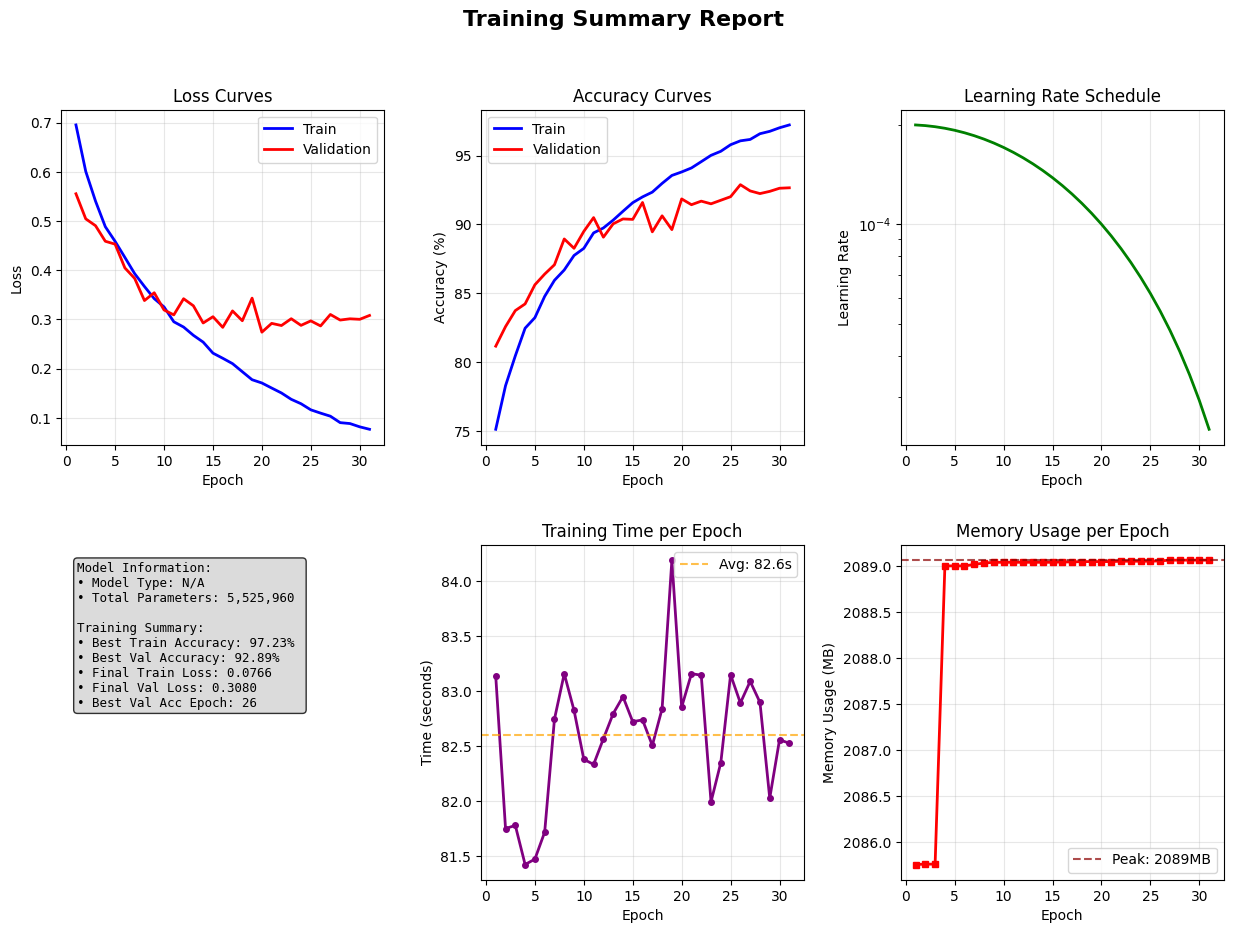

In [19]:
# Generate and save plots
logger.info("Generating plots...")
save_all_plots(
    metrics_tracker=metrics_phase2,
    run_dir=run_dir,
    y_true=test_results['targets'],
    y_pred=test_results['predictions'],
)

# Create comprehensive training summary plot
model_info = {
    'model_name': model_name,
    'total_params': total_params,
}

summary_plot = create_training_summary_plot(metrics_phase2, model_info)
summary_plot.savefig(
    os.path.join(run_dir, 'plots', 'training_summary.png'),
    bbox_inches='tight', dpi=300
)

## Explain

In [20]:
# model_name = "vit_tiny_patch16_224"
# checkpoint_path = ""

# model = create_linear_attention_vit(
#     model_name,
#     pretrained=False,
#     num_classes=len(CLASSES)
# )

# load_checkpoint(
#     checkpoint_path,
#     model,
#     device=DEVICE
# )

model.to(DEVICE).eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): LinearAttentionBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): LinearMultiheadAttention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (out_proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.1, inplace=False)
        (attn_drop): Dropout(p=0.1, inplace=False)
      )
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.1, inplace=False)
        (fc2): Linear(in_features=768, out_features=192, bias=True)
       

In [21]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

### LAGRA

In [22]:
idx = np.random.randint(len(test_ds))

x, y_true = test_ds[idx] # test sample
xb = x.unsqueeze(0).to(DEVICE)

In [23]:
proposal_model = LAGRA(model, has_cls=True, blocks_attr="blocks")

out = proposal_model.attribute(xb, use_logits=True)

In [24]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.0709, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(0.0656, device='cuda:0', grad_fn=<MeanBackward0>))

### GradCAM

In [25]:
gradcam_model = ViTGradCAM(model, has_cls=True)

out = gradcam_model.attribute(xb)

In [26]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.7557, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(0.3719, device='cuda:0', grad_fn=<MeanBackward0>))

### Integrated Gradients

In [27]:
ig_model = IntegratedGradient(model, m_steps=32)

out = ig_model.attribute(xb)

In [28]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.1513, device='cuda:0'),
 tensor(0.0363, device='cuda:0'))

### Rollout

In [29]:
rollout_model = Rollout(model, has_cls=True)

out = rollout_model.attribute(xb)

In [30]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.0874, device='cuda:0'),
 tensor(0.0865, device='cuda:0'))

## Visualization

1294


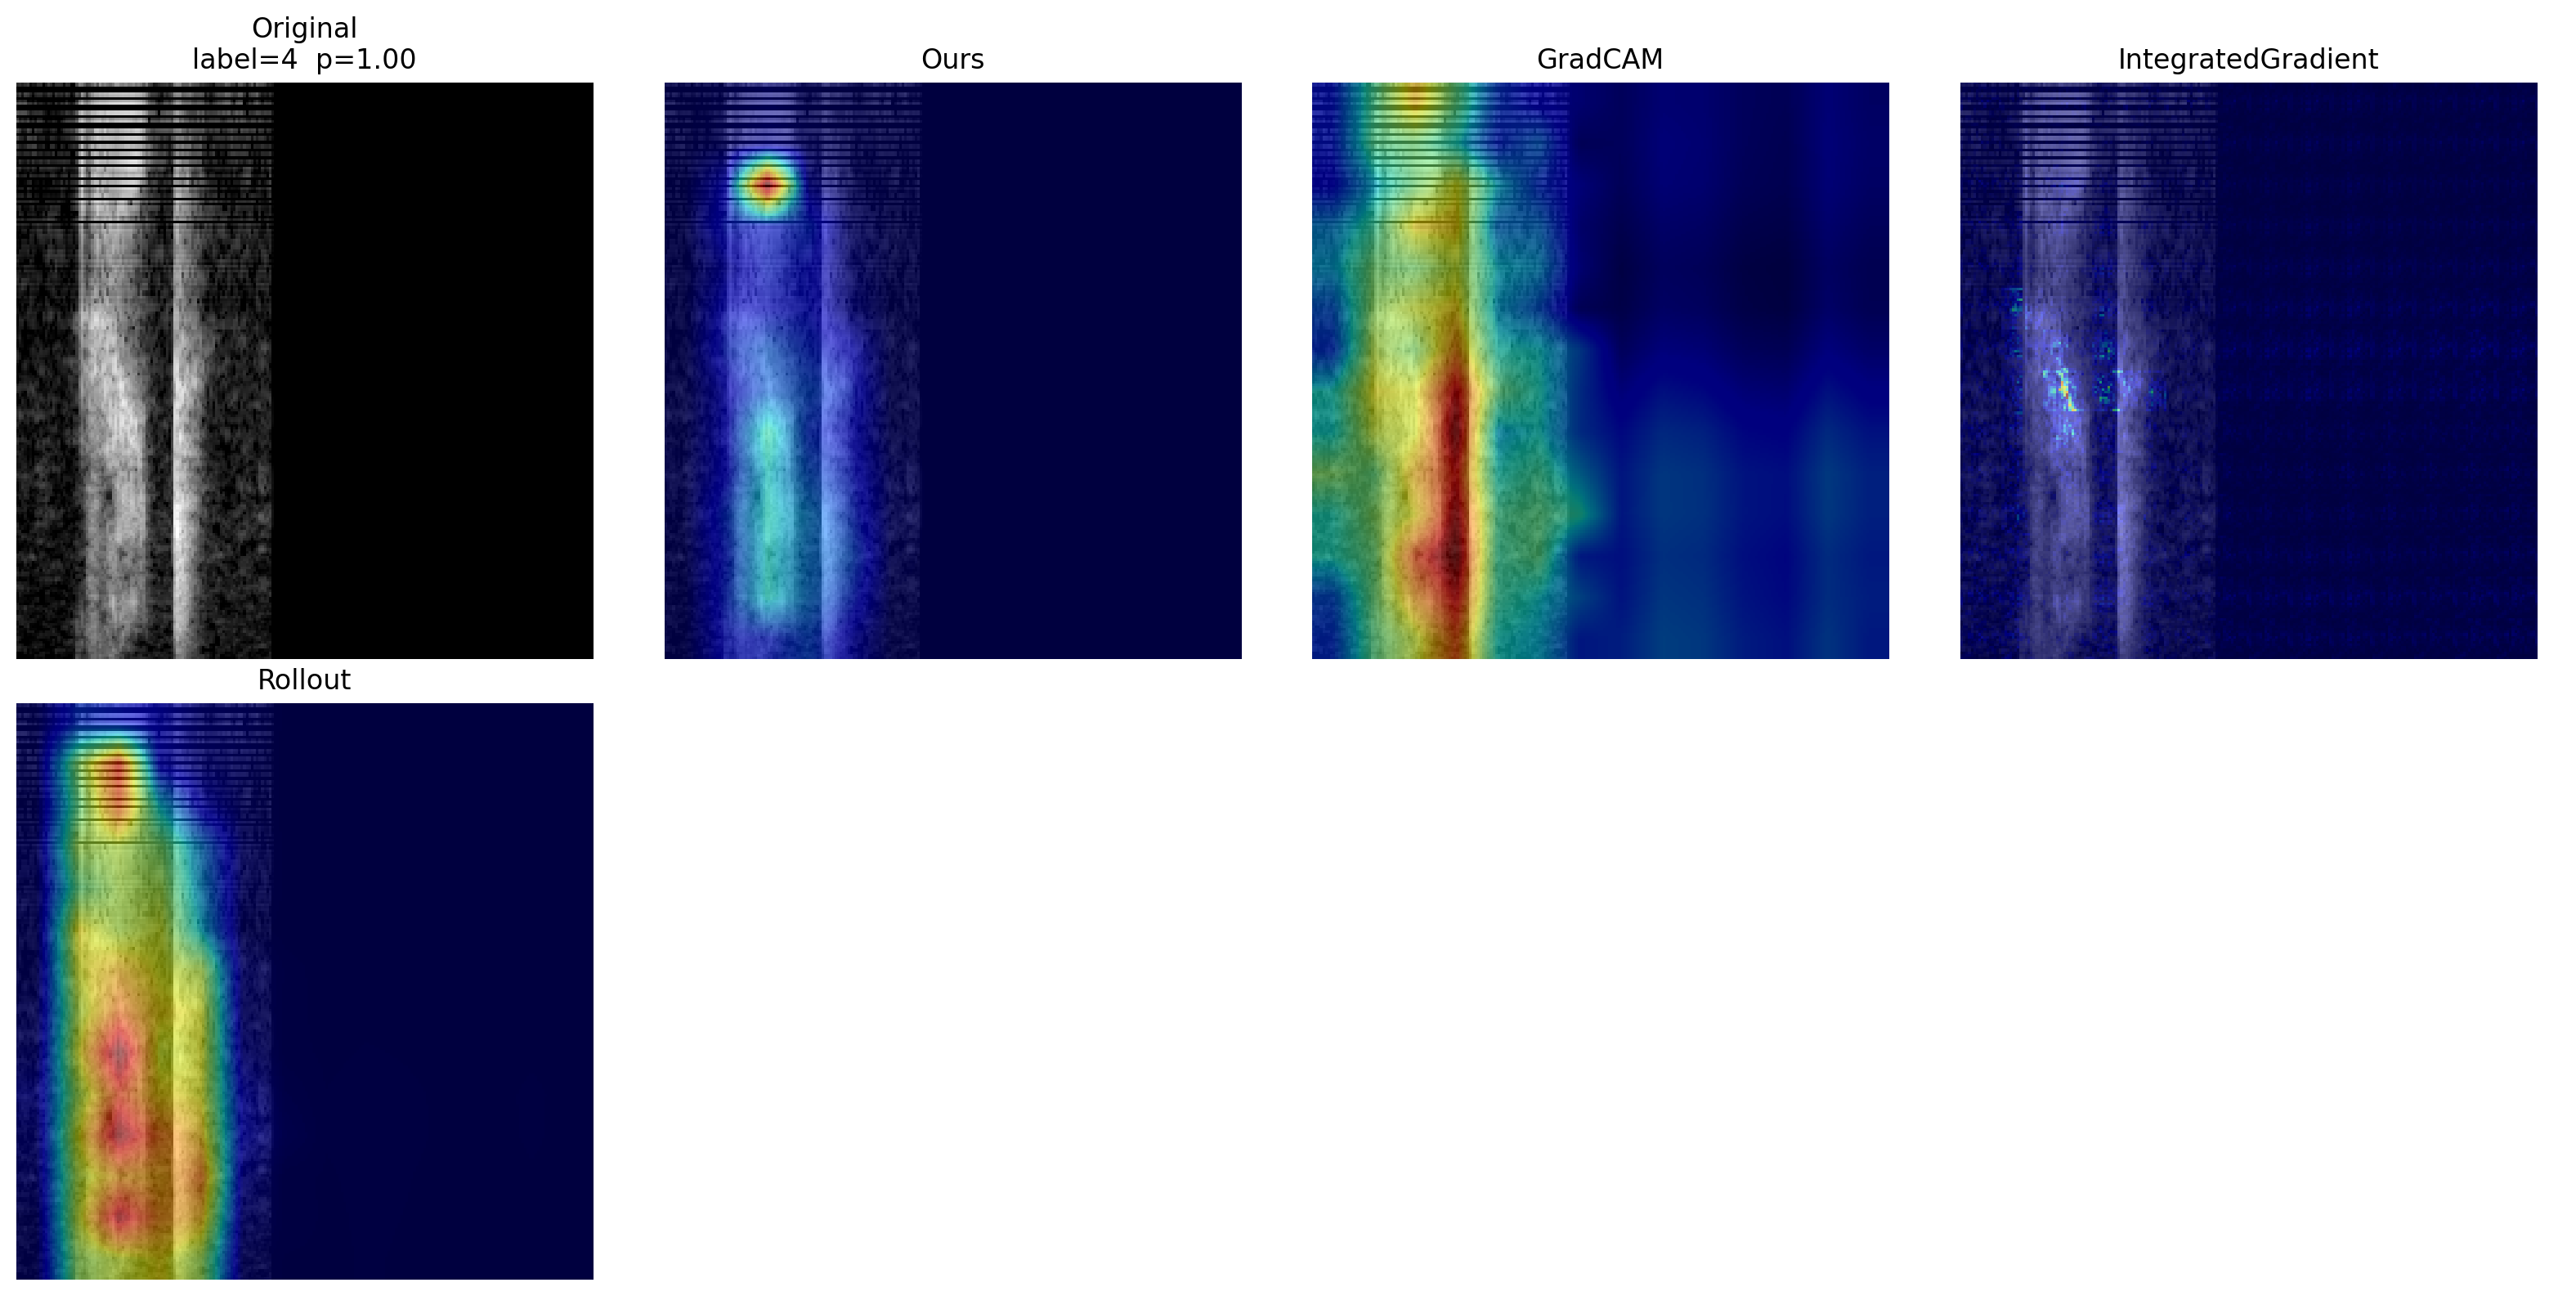

In [31]:
idx = np.random.randint(len(test_ds))
print(idx)

_ = visualize_methods(
    test_ds, idx,
    {
        "Ours": proposal_model,
        "GradCAM": gradcam_model,
        "IntegratedGradient": ig_model,
        "Rollout": rollout_model
    },
    use_pred=True,
    device=DEVICE,
)

## Evaluate Explain methods

In [32]:
methods = {
    "Ours": proposal_model,
    "GradCAM": gradcam_model,
    "IG": ig_model,
    "Rollout": rollout_model
}

results = {}
for name, attr in methods.items():
    print(f"Evaluating {name}...")
    stats_faith = evaluate_xai_method_dataset(
        attributor=attr,
        dataset=test_ds,
        device=DEVICE,
        use_pred=True,
        max_samples=500,
        steps=20,
        baseline=None,
        use_logits=True,
        verbose_every=50,
    )

    stats_cs = evaluate_class_specificity_cosine(
        attributor=attr,
        dataset=test_ds,
        device=DEVICE,
        max_samples=500,
        use_logits=True,
        use_pred=True,
        verbose_every=50,
    )

    metrics = {
        **stats_faith,
        "cosine_cs_mean": stats_cs["cosine_cs_mean"],
        "cosine_cs_std": stats_cs["cosine_cs_std"],
    }
    results[name] = metrics
    print(f"Results for {name}: {metrics}")
    print("-" * 50)

Evaluating Ours...
[50/500] AUC_del_mean=0.1820, AUC_ins_mean=0.3866, entropy_mean=0.7520
[100/500] AUC_del_mean=0.1902, AUC_ins_mean=0.4097, entropy_mean=0.7468
[150/500] AUC_del_mean=0.1883, AUC_ins_mean=0.4060, entropy_mean=0.7524
[200/500] AUC_del_mean=0.1885, AUC_ins_mean=0.3984, entropy_mean=0.7502
[250/500] AUC_del_mean=0.1815, AUC_ins_mean=0.3922, entropy_mean=0.7515
[300/500] AUC_del_mean=0.1810, AUC_ins_mean=0.3937, entropy_mean=0.7492
[350/500] AUC_del_mean=0.1799, AUC_ins_mean=0.3874, entropy_mean=0.7500
[400/500] AUC_del_mean=0.1770, AUC_ins_mean=0.3857, entropy_mean=0.7519
[450/500] AUC_del_mean=0.1792, AUC_ins_mean=0.3865, entropy_mean=0.7519
[500/500] AUC_del_mean=0.1767, AUC_ins_mean=0.3827, entropy_mean=0.7532
[50/500] cosine_cs_mean=0.8151
[100/500] cosine_cs_mean=0.8228
[150/500] cosine_cs_mean=0.8240
[200/500] cosine_cs_mean=0.8268
[250/500] cosine_cs_mean=0.8271
[300/500] cosine_cs_mean=0.8286
[350/500] cosine_cs_mean=0.8288
[400/500] cosine_cs_mean=0.8285
[450/50

In [33]:
results

{'Ours': {'auc_del_mean': 0.17674679169463703,
  'auc_ins_mean': 0.38269136207464216,
  'entropy_mean': 0.7531878815656234,
  'gini_mean': 0.9577284678164869,
  'n_samples': 500,
  'cosine_cs_mean': 0.8266364477872848,
  'cosine_cs_std': 0.11243362066853571},
 'GradCAM': {'auc_del_mean': 0.22069234466643914,
  'auc_ins_mean': 0.40780253688224877,
  'entropy_mean': 0.9978478091962103,
  'gini_mean': 0.9947770986631512,
  'n_samples': 500,
  'cosine_cs_mean': 0.05534261511941441,
  'cosine_cs_std': 0.6061206593728267},
 'IG': {'auc_del_mean': 0.17373911708149126,
  'auc_ins_mean': 0.4324189477973888,
  'entropy_mean': 0.963037716329593,
  'gini_mean': 0.9916123105650768,
  'n_samples': 500,
  'cosine_cs_mean': 0.6399049487113952,
  'cosine_cs_std': 0.09365350900994578},
 'Rollout': {'auc_del_mean': 0.1884898792636745,
  'auc_ins_mean': 0.38223521693829593,
  'entropy_mean': 0.7369442478936558,
  'gini_mean': 0.9625817954931408,
  'n_samples': 500,
  'cosine_cs_mean': 1.000000011086464,
 